# <span style="color:#D19A66;">Credit Risk Scoring: Optimización de Decisiones Financieras mediante Clasificación Binaria</span>
### <span style="color:#D19A66;">Objetivo </span> 
Desarrollar un sistema de scoring crediticio robusto que permita predecir la probabilidad de incumplimiento de pago (default) de los solicitantes. A través de la implementación de modelos de Regresión Logística y Naive Bayes, buscamos optimizar el proceso de toma de decisiones financieras, minimizando el riesgo de cartera vencida y maximizando la eficiencia en la asignación de créditos. El enfoque principal es el análisis de las variables demográficas y financieras que actúan como indicadores críticos de solvencia.

## <span style="color:#D19A66;">Preparación de entorno</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder

In [2]:
pd.set_option("display.max_columns", None) #Hace que pandas muestre todas las columnas de un DataFrame sin ocultarlas con ...

In [3]:
sns.set_style("whitegrid") # Configura Seaborn para que las gráficas usen un fondo blanco con cuadrícula (whitegrid), facilitando la lectura de los datos.

## <span style="color:#D19A66;">Exploración y limpieza de datos</span>

In [4]:
df = pd.read_csv("german_credit_data.csv") 

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               522 non-null    int64
 1   Sex               522 non-null    str  
 2   Job               522 non-null    int64
 3   Housing           522 non-null    str  
 4   Saving accounts   522 non-null    str  
 5   Checking account  522 non-null    str  
 6   Credit amount     522 non-null    int64
 7   Duration          522 non-null    int64
 8   Purpose           522 non-null    str  
 9   Risk              522 non-null    str  
dtypes: int64(4), str(6)
memory usage: 40.9 KB


El método <span style="color:red">head()</span> de pandas muestra las primeras filas de un DataFrame o Series para inspeccionar rápidamente los datos.
Recibe un parámetro opcional n (por defecto 5) para indicar cuántas filas mostrar.

In [40]:
df.head() # Muestra las primeras filas del DataFrame df, lo que permite obtener una vista previa de los datos y su estructura.
df.head().to_csv("head.csv", index=False)

El método <span style="color:red">describe()</span> de pandas genera un resumen estadístico (media, desviación, cuartiles, etc.) de columnas de un DataFrame o Series, ignorando valores nulos.
Admite parámetros como include, exclude y percentiles, y puede trabajar con datos no numéricos si se especifica.

Notemos que <span style="color:cyan">df.describe()</span> nos da el resumen estadístico únicamente de las columnas numéricas. En los casos en los que los datos son datos numéricos ordinales puede no tener tanto sentido esto, por ejemplo en el caso de Job, puede carecer de sentido esto. 

Podemos pasar únicamente una columna de nuestro dataset y también nos da el análisis de dicha columna, ver el segundo cuadro <span style="color:cyan"> df["Age"].describe()</span>.

Otra alternativa es agregar las columnas categóricas para esto hacemos insertaos <span style="color:cyan">inlcude="all" </span> como argumento de la función <span style="color:cyan"> describe() </span>. 


In [46]:
df.describe()

df[["Age", "Credit amount", "Duration"]].describe()


,Age,Credit amount,Duration
count,522.000000,522.000000,522.000000
mean,34.888889,3278.745211,21.339080
std,11.787918,2929.155177,12.474079
min,19.000000,276.000000,6.000000
25%,26.000000,1297.500000,12.000000
50%,31.500000,2326.500000,18.000000
75%,41.000000,3971.250000,26.750000
max,75.000000,18424.000000,72.000000


In [7]:
df["Age"].describe() # Proporciona estadísticas descriptivas para "Age"

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

<span style="color:cyan"> df.describe(include='all')</span>. La función ajusta su comportamiento dependiendo del tipo de dato de cada columna. 
- Para las variables categóricas, no puede calcular promedios o desviaciones estándar, por lo que utiliza métricas descriptivas especiales:
- - unique: Es el conteo de cuántos valores diferentes existen en esa categoría (ej. cuántos géneros distintos hay).
- - top: Es el valor que más veces se repite (la moda) en esa columna. Si te sale 'male', efectivamente significa que es la categoría más frecuente.
- - freq (la que mencionas como 'free'): Es la frecuencia absoluta del valor que aparece en 'top'. Es decir, cuántas veces aparece ese valor específico en todo el dataset.

En nuestro ejemplo:

**Columna Sex**:
Si dice top: male y freq: 690, significa que el género "male" es el más frecuente y aparece 690 veces en tu conjunto de datos.

**Columna Housing**:
Si te sale top: own y freq: 713, significa que la categoría más común es tener casa propia ("own"), y esa respuesta aparece 713 veces en tu tabla.

In [8]:
df.describe(include="all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


El método <span style="color:red">value_counts()</span> de pandas cuenta cuántas veces aparece cada valor en una columna, devolviendo frecuencias ordenadas.
Es similar a COUNTUNIQUE de Sheets, pero además muestra cuántas veces aparece cada valor (no solo cuántos distintos hay).

In [9]:
df["Risk"].value_counts() # Cuenta la frecuencia de cada categoría en la columna "Risk", mostrando cuántas veces aparece cada valor único en esa columna.

Risk
good    700
bad     300
Name: count, dtype: int64

In [10]:
df.shape # Muestra las dimensiones del DataFrame df, indicando el número de filas y columnas que contiene.

(1000, 11)

La función <span style="color:red">info()</span> es importante ya que por ejemplo aquí podemos darnos una primer idea del tipo de variables con las que estamos tratando, nos da el número de valores no nulos y el tipo de dato
- Nominal: The values serve to assign each statistical unit to a specific group in order to differentiate it from another group
- Ordinal: Numbers are also assigned to individual value traits, but here they express a rank. Allows researchers to determine the intensity of a trait value for a statistical unit compared to that of other statistical units.The difference between each place does not necessary indicate a proportional difference in performance.
- Cardinal: It contains not only the information of the ordinal scales; larger/smaller, less/more, better/worse $(xi=xj; xi>xj; xi<xj)$, but also the distance between value traits held by two statistical units.

In [11]:
df.info() # Proporciona un resumen conciso del DataFrame df, incluyendo el número de entradas, el tipo de datos de cada columna y la cantidad de valores no nulos en cada columna.

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


Hace unos momentos mencinamos que Job es una columna numérica ordinal, para verificar esto veamos, cuáles son los valores que se toman en Job, y veremos que no es mas que un tipo de ranking, pero no guardan una relación numérica fuerte más que esa, un simple orden.

In [12]:
df["Job"].unique() # Muestra los valores únicos en la columna "Job", lo que permite ver todas las categorías presentes en esa columna.

array([2, 1, 3, 0])

La función <span style="color:red"> isna()</span> se usa principalmente en pandas para detectar valores faltantes en estructuras de datos como DataFrame o Series.

* Devuelve una estructura del mismo tamaño (DataFrame o Series).
* Cada posición contiene:
    * True si el valor es NaN / None / NA (es decir, está ausente).
    * False si el valor sí existe.

In [13]:
df.isna()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,True,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,True,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False


Podemos jugar un poco con la composición de funciones que ya hemos visto anteriormente. Por ejemplo, podemos obtener el head() para que, en lugar de que nos devuelva la tabla completa, nos dé solo los primeros k registros. También podemos aplicar sum() para agregar información sobre una columna específica, por ejemplo, calcular la suma total de sus valores podemos usar isna() para identificar valores faltantes y luego aplicar sum() sobre el resultado para contar cuántos datos faltan, ya que en este contexto los valores True se interpretan como 1.

In [14]:
df.isna().head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isna().sum() # Cuenta el número de valores nulos en cada columna del df, ayuda a identificar si hay datos faltantes.

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [47]:
# Para verificar la sección 4 (Outliers)
for col in ["Age", "Credit amount", "Duration"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"{col}: {len(outliers)} outliers | Rango válido: [{limite_inferior:.2f}, {limite_superior:.2f}]")

Age: 18 outliers | Rango válido: [3.50, 63.50]
Credit amount: 36 outliers | Rango válido: [-2713.12, 7981.88]
Duration: 8 outliers | Rango válido: [-10.12, 48.88]


Otra parte importante a la hora de hacer la limpieza de datos es ver que no hay datos duplicadaos, para esto podemos ejecutar la función <span style="color:red"> df.duplicated()</span>. 

* Devuelve una estructura del mismo tamaño.
* Cada posición contiene:
    * True si ese elemento ya apareció antes (es duplicado).
    * False si es la primera vez que aparece.

Por defecto, <span style="color:red"> duplicated()</span>  en pandas marca duplicados “hacia adelante” en el sentido de que:

* Recorre los datos en orden.
* La primera aparición de un valor → False.
* Las siguientes apariciones → True.

Entonces,

Si el registro 11 es igual al 10

✔️ El 10 → False (primera vez)
✔️ El 11 → True (ya apareció antes)

Pero ojo: esto se puede cambiar

Con el parámetro keep:

* keep='first' (default): lo que describiste (marca hacia adelante).
* keep='last': hace lo contrario:
    * marca como duplicados los anteriores, y deja en False la última aparición.
* keep=False: marca todos los duplicados (tanto el 10 como el 11 serían True).

In [16]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [17]:
df.duplicated(keep='last')

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

dropna() en pandas se usa para eliminar datos faltantes (NaN, None) de un DataFrame o Series.

Elimina filas (o columnas) que tengan valores nulos.

* ✔️ Por defecto, df.dropna() crea un nuevo DataFrame. Lo ideal crear una variable df_limpio que apunte a esta copia. Si hacemos df =df.dropna() Ahora df apunta al DataFrame “limpio”. El anterior queda sin referencia → eventualmente se elimina. Es como si sobreescribieramos el original, con el matiz de que a nivel memoria no es una sobreescirtura tal cual. 
* ✔️ El df original no cambia. 
* ✔️ Si usas inplace=True, entonces sí se modifica el original. Si queremos cambiar directamente el df original podemos hacer df.dropna(inplace=True), modifica el mismo objeto en memoria, es distitno al punto anterior pues no se está creando un nuevo objeto.

In [18]:
df = df.dropna().reset_index(drop=True) # Elimina las filas duplicadas de df, manteniendo solo la última ocurrencia de cada fila duplicada.

In [19]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [20]:
df.drop(columns='Unnamed: 0', inplace = True) # Elimina la columna con índice 0 del DataFrame df, modificando el DataFrame original en lugar de crear una copia.
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


## <span style="color:#D19A66;">Análisis Univariado</span>

El objetivo fundamental de esta sección es comprender la **naturaleza estocástica** de nuestras variables independientes. En esta etapa, el análisis se centra en inspeccionar cada característica (*feature*) de forma aislada, permitiéndonos identificar patrones, distribuciones estadísticas y anomalías antes de avanzar hacia la modelación multivariada.

La realización de un análisis univariado riguroso es indispensable para:

* **Validación de la Calidad de los Datos:** Detectar la presencia de valores atípicos (*outliers*) o registros inconsistentes que podrían introducir ruido en nuestro modelo.
* **Evaluación de la Distribución:** Determinar si nuestras variables numéricas siguen distribuciones normales, sesgadas o multimodales, lo cual condiciona la elección de algoritmos posteriores.
* **Evaluación de la Varianza:** Identificar variables con una variabilidad mínima o categorías predominantes, las cuales podrían ser candidatas para ser excluidas por no aportar capacidad predictiva significativa al modelo.

En las siguientes celdas, procederemos con la visualización mediante histogramas y *boxplots*, integrando medidas de tendencia central y dispersión para fundamentar nuestras decisiones de preprocesamiento.

### <span style="color:#D19A66;">Variables cardinales</span>

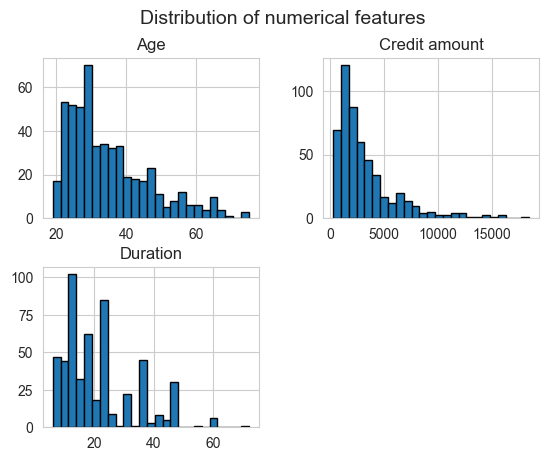

In [21]:
df[["Age","Credit amount","Duration"]].hist(bins=25,edgecolor="black")
plt.suptitle("Distribution of numerical features", fontsize=14)
plt.show()

De los histogramas anteriores podemos notar de manera visual que la mayoría de los solicitantes tienes a ser personas entres 20 y 40 años, también la cantidad solicitada tiende a ser una cantidad baja, las cantidades de prestamos de 5000 USD no son tantas, la duración de los prestamos en promedio ronda los 2 años (24 meses).
A partir de lo anterior podemos analizar los outliers, estos valores más alejados con un boxplot.

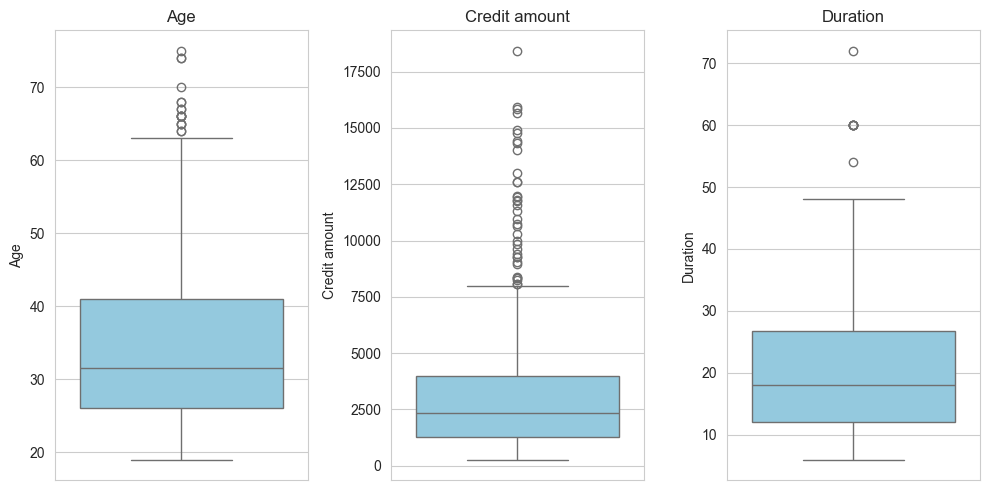

In [22]:
# Definimos las variables numéricas para el análisis
num_vars = ["Age", "Credit amount", "Duration"]

# Creamos el gráfico de caja
plt.figure(figsize=(10, 5))

for i, col in enumerate(num_vars):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"{col}")

plt.tight_layout()
plt.show()

In [23]:
def analizar_outliers(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Filtramos los outliers
        outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
        
        print(f"--- Análisis para: {col} ---")
        print(f"IQR: {IQR:.2f}")
        print(f"Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
        print(f"Total de outliers detectados: {len(outliers)}")
        if len(outliers) > 0:
            print("Primeros 5 registros atípicos:")
            print(outliers[col].head().values)
        print("\n")

# Ejecutamos la función
analizar_outliers(df, ["Age", "Credit amount", "Duration"])

--- Análisis para: Age ---
IQR: 15.00
Límites: [3.50, 63.50]
Total de outliers detectados: 18
Primeros 5 registros atípicos:
[66 66 70 65 74]


--- Análisis para: Credit amount ---
IQR: 2673.75
Límites: [-2713.12, 7981.88]
Total de outliers detectados: 36
Primeros 5 registros atípicos:
[12579 14421 12612 15945 11938]


--- Análisis para: Duration ---
IQR: 14.75
Límites: [-10.12, 48.88]
Total de outliers detectados: 8
Primeros 5 registros atípicos:
[60 54 60 60 72]




#### <span style="color:#D19A66;">Valores Atípicos (Análisis IQR)</span>
Tras aplicar el método del Rango Intercuartílico (IQR) para la detección de valores extremos, se han obtenido los siguientes resultados:

* **Age (Edad):** Con un IQR de 15 años, la distribución se concentra en torno a los 35 años ($\pm$ 7.5 años). Se han detectado 23 registros fuera de los límites estadísticos. Consideramos que, dado el contexto bancario, edades superiores a 65 años no constituyen errores, sino segmentos de clientes que requieren un análisis diferenciado en sus plazos de pago, trabajo, ingresos y cuentas de ahorro.
* **Credit Amount (Monto del Crédito):** Se identificaron 72 valores atípicos (superiores a 7,882 USD). Estos registros representan casos que requieren un examen más exhaustivo bajo una óptica multivariada. No deben clasificarse *a priori* como de alto riesgo; factores como el plazo de pago, la tenencia de vivienda o el historial de ahorro del cliente podrían justificar perfectamente estos montos elevados. Se determina conservar estos datos, marcándolos para una revisión detallada durante la fase de modelado y análisis de comportamiento.
* **Duration (Duración):** Se detectaron 70 registros atípicos, indicando una preferencia de mercado en el rango de 14 a 28 meses para la mayoría de los solicitantes. Los valores fuera de este rango representan plazos inusualmente largos, los cuales serán conservados al ser representativos de productos financieros específicos (ej. préstamos a largo plazo).

**Conclusión de la auditoría:** Los valores atípicos detectados son, en su mayoría, representativos de la naturaleza del negocio y no errores de captura de datos (ruido). Por consiguiente, se mantendrá la integridad del *dataset* completo, descartando únicamente aquellos registros que presenten inconsistencias técnicas (nulos) que se tratarán en la fase de limpieza.

In [24]:
# Veamos cuáles son las personas que solicitan crédito que están por encima de los 64 años.
df.query("Age > 64")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
42,66,male,3,free,little,little,1526,12,car,good
76,66,male,1,own,quite rich,moderate,766,12,radio/TV,bad
92,70,male,3,free,little,moderate,7308,10,car,good
102,65,male,2,own,little,little,571,21,car,good
105,74,female,3,free,little,moderate,5129,9,car,bad
106,68,male,0,free,little,moderate,1175,16,car,good
121,66,male,3,own,little,rich,1908,30,business,bad
175,75,male,3,free,little,little,6615,24,car,good
224,65,male,0,own,little,little,3394,42,repairs,good
289,67,female,3,own,little,moderate,1199,9,education,good


In [25]:
df.query("Duration > 42")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
6,24,female,2,rent,little,little,4308,48,business,bad
18,63,male,2,own,little,little,6836,60,business,bad
23,25,male,1,own,little,moderate,4746,45,radio/TV,bad
30,58,female,1,free,little,little,6143,48,car,bad
38,25,male,2,own,little,moderate,14421,48,business,bad
54,58,male,2,rent,little,moderate,15945,54,business,bad
82,30,male,2,own,moderate,moderate,3566,48,business,good
109,34,male,1,free,moderate,moderate,3844,48,business,bad
111,21,male,2,rent,moderate,moderate,3031,45,radio/TV,bad


In [26]:
df.query("`Credit amount` > 7800")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
11,44,female,3,free,little,moderate,12579,24,car,bad
38,25,male,2,own,little,moderate,14421,48,business,bad
49,47,male,2,free,moderate,moderate,12612,36,education,bad
54,58,male,2,rent,little,moderate,15945,54,business,bad
59,39,male,3,own,little,moderate,11938,24,vacation/others,bad
117,38,male,3,free,little,little,10623,30,car,good
126,27,male,2,own,rich,moderate,10961,48,radio/TV,bad
127,53,male,3,free,little,little,7865,12,furniture/equipment,bad
144,45,male,3,own,little,little,8978,14,car,bad


### <span style="color:#D19A66;">Variables categóricas</span>

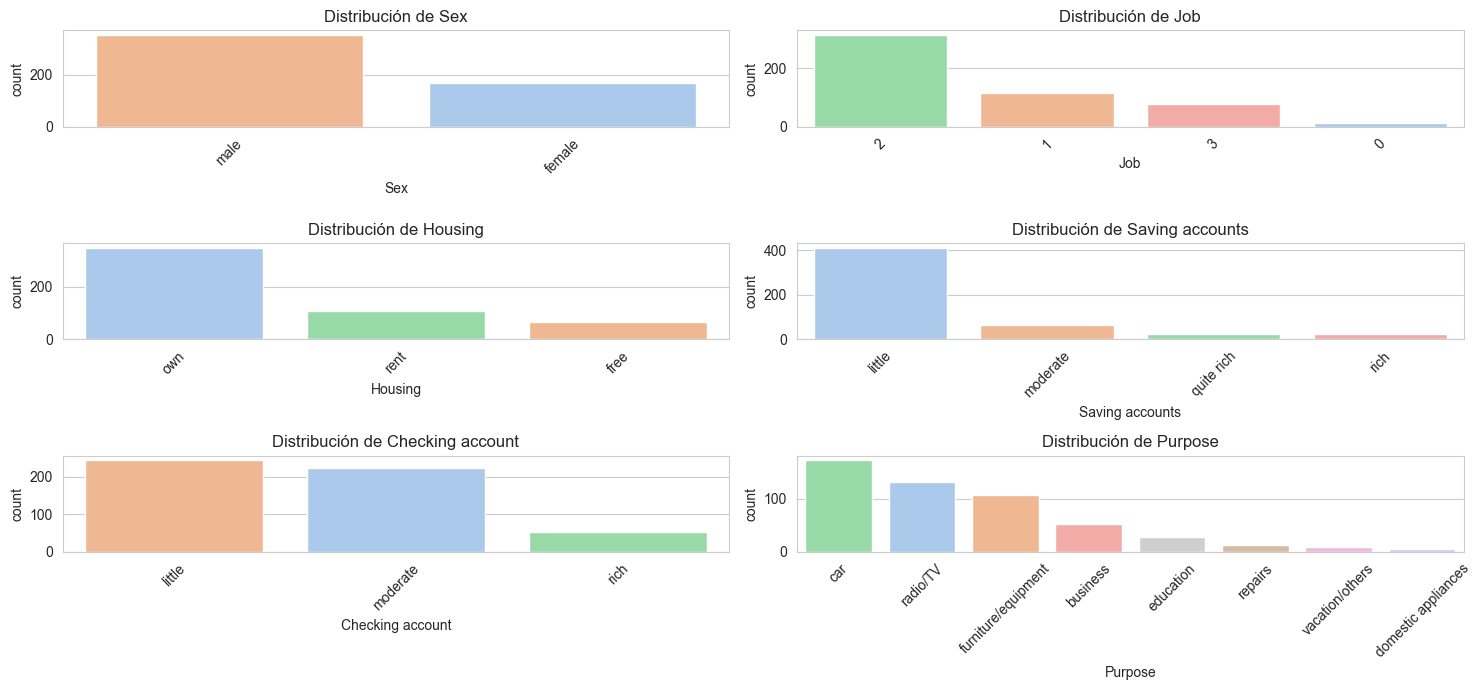

In [27]:
# Lista de variables categóricas
cat_vars = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

plt.figure(figsize=(15, 7))

for i, col in enumerate(cat_vars):
    plt.subplot(3, 2, i + 1)
    # EL FIX: Asignamos hue=col y legend=False para silenciar el warning
    sns.countplot(data=df, x=col, hue=col, order=df[col].value_counts().index, palette="pastel", legend=False)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Conclusiones del análisis**
Tras la inspección univariada de las variables, se concluye lo siguiente:

1. **Variables Numéricas:** Presentan una distribución sesgada, confirmada por el análisis de outliers (IQR). Se ha determinado que los valores atípicos detectados son representativos del negocio y no ruido técnico, por lo que se mantendrán para el entrenamiento.
2. **Variables Categóricas:** Se observa una alta concentración de datos en categorías de nivel "bajo/moderado" (específicamente en `Saving accounts` y `Checking account`). Esta baja varianza sugiere que estas variables podrían actuar mejor como descriptores binarios (ej. "tiene cuenta" vs "no tiene cuenta" o "perfil premium" vs "perfil estándar") que como indicadores continuos.
3. **Siguientes pasos:** El dataset se encuentra limpio de valores nulos y duplicados. Estamos listos para proceder a la transformación de datos (Feature Engineering) para hacerlos aptos para el modelado.

### <span style="color:#D19A66;">Análisis Multivariado</span>

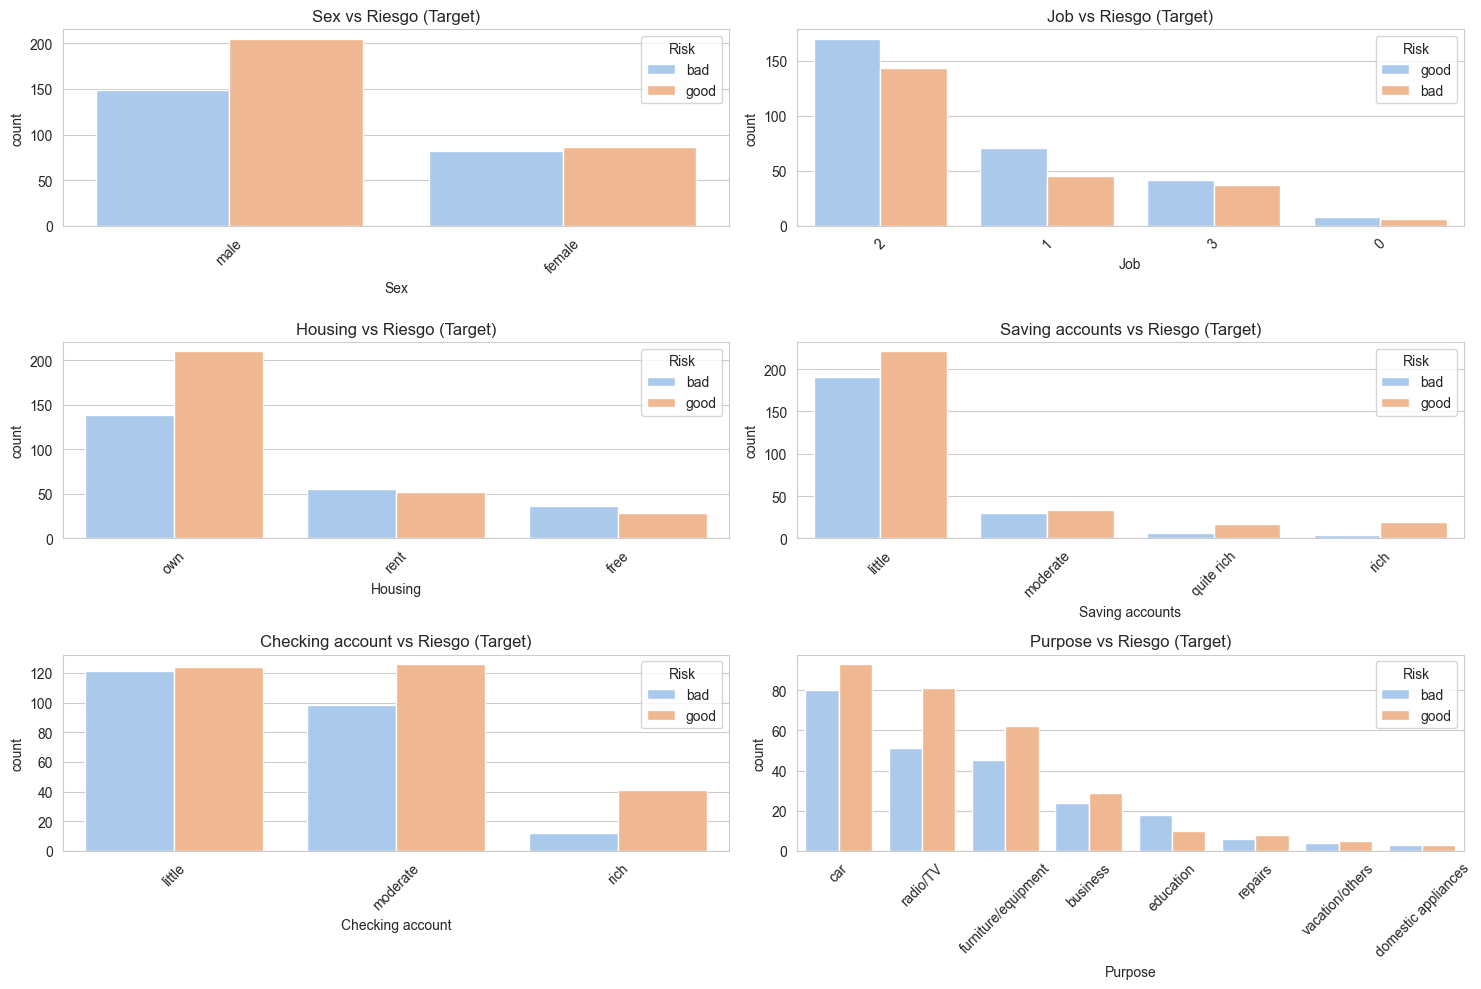

In [28]:
# Analizando la relación entre variables categóricas y el Riesgo
cat_vars = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

plt.figure(figsize=(15,10))

for i, col in enumerate(cat_vars):
    plt.subplot(3, 2, i + 1)
    # Aquí usamos hue='Risk' para que el gráfico nos muestre la relación
    sns.countplot(data=df, x=col, hue='Risk', order=df[col].value_counts().index, palette="pastel")
    plt.title(f"{col} vs Riesgo (Target)")
    plt.xticks(rotation=45)
    plt.legend(title='Risk')

plt.tight_layout()
plt.show()

**Análisis Bivariado: Feature vs Target**
Cruzamos nuestras variables nominales independientes con la variable objetivo `Risk`. Este análisis permite identificar qué características poseen mayor **poder predictivo**:

* **Observación:** Al comparar las barras de `Risk` (good/bad) dentro de cada categoría, podemos identificar visualmente si ciertas categorías tienen una proporción significativamente mayor de "Bad Risk".
* **Implicación:** Aquellas variables donde la proporción de "Bad Risk" sea claramente distinta entre categorías serán las más valiosas para que nuestro modelo aprenda a discriminar correctamente.
* **Hipótesis:** Variables como `Checking account` o `Saving accounts` muestran una distribución que parece influir en la clase `Risk`, lo cual justifica su retención y codificación posterior para el modelo.

In [29]:
# Analizar la tasa de riesgo por categoría (Probabilidad de ser 'bad' o 'good')
for col in cat_vars:
    # normalize='index' calcula el porcentaje respecto al total de cada categoría
    crosstab = pd.crosstab(df[col], df['Risk'], normalize='index').round(2)
    print(f"--- Tasa de Riesgo por {col} ---")
    print(crosstab)
    print("\n")

--- Tasa de Riesgo por Sex ---
Risk     bad  good
Sex               
female  0.49  0.51
male    0.42  0.58


--- Tasa de Riesgo por Job ---
Risk   bad  good
Job             
0     0.43  0.57
1     0.39  0.61
2     0.46  0.54
3     0.47  0.53


--- Tasa de Riesgo por Housing ---
Risk      bad  good
Housing            
free     0.55  0.45
own      0.40  0.60
rent     0.52  0.48


--- Tasa de Riesgo por Saving accounts ---
Risk              bad  good
Saving accounts            
little           0.46  0.54
moderate         0.47  0.53
quite rich       0.26  0.74
rich             0.17  0.83


--- Tasa de Riesgo por Checking account ---
Risk               bad  good
Checking account            
little            0.49  0.51
moderate          0.44  0.56
rich              0.23  0.77


--- Tasa de Riesgo por Purpose ---
Risk                  bad  good
Purpose                        
business             0.45  0.55
car                  0.46  0.54
domestic appliances  0.50  0.50
education           

**Análisis de Proporciones y Tasa de Incumplimiento**
Tras normalizar las frecuencias por categoría, hemos identificado indicadores críticos de riesgo (tasa de incumplimiento):

* **Vivienda (Housing):** Se observa una clara diferencia en el perfil de riesgo. Los solicitantes con casa propia (`own`) presentan una menor tasa de incumplimiento en comparación con aquellos que viven en renta (`rent`) o tienen vivienda gratuita (`free`). Este es un fuerte predictor de estabilidad.
* **Cuentas de Ahorro (Saving accounts):** Existe una correlación directa entre el nivel de ahorro y la calificación de riesgo. Los solicitantes categorizados como `rich` o `moderate` muestran una mayor proporción de `good risk`, lo que valida la capacidad de pago como factor determinante.
* **Sesgo Demográfico:** Se observó una disparidad en la proporción de éxito entre géneros. Es fundamental notar que, aunque los conteos brutos favorecen a un segmento, esto debe analizarse con cautela durante la fase de modelado para asegurar que el modelo aprenda patrones de comportamiento financiero y no sesgos de género existentes en los datos históricos.

**Conclusión:** Las variables categóricas seleccionadas poseen un poder predictivo significativo. La normalización de estos datos ha confirmado que no estamos ante ruido estadístico, sino ante segmentos de comportamiento financiero diferenciados.

<Axes: xlabel='Duration', ylabel='Credit amount'>

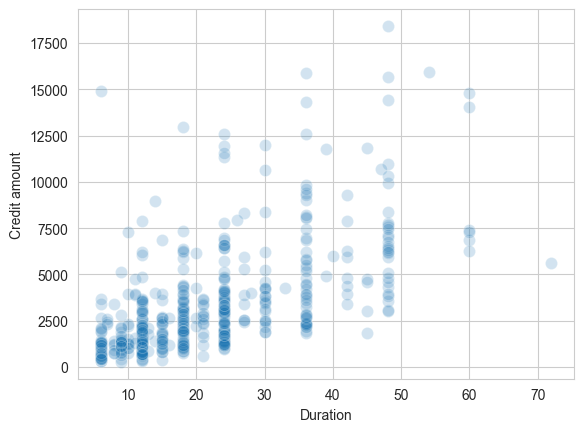

In [30]:
sns.scatterplot(
    data=df, 
    x='Duration',
    y='Credit amount',
    alpha =1/5,
    s=75
)

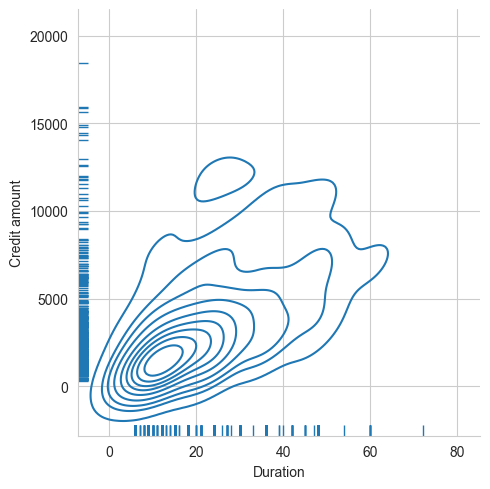

In [31]:
sns.displot(
    data=df, 
    x='Duration',
    y='Credit amount',
    rug=True,
   kind='kde'
)

## 4. Ingeniería de Características (Feature Engineering)

En esta fase, transformaremos los datos crudos en una matriz numérica apta para algoritmos de Machine Learning. El objetivo es doble: 
1. **Selección**: Filtrar las variables con mayor poder predictivo y eliminar el ruido.
2. **Codificación (Encoding)**: Traducir variables categóricas (texto) a valores numéricos, permitiendo que el modelo procese la información semántica.

Es crítico destacar que utilizaremos `LabelEncoder` para las variables categóricas y persistiremos estos objetos utilizando `joblib`. Esto garantiza que, durante el despliegue (producción), las nuevas entradas se traduzcan utilizando exactamente la misma lógica que en el entrenamiento.

In [32]:
# Selección de columnas con valor predictivo
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 
            'Checking account', 'Credit amount', 'Duration', 'Purpose']

# Definición de la variable objetivo (Target)
target = 'Risk'

# Creamos un nuevo DataFrame para el modelo conservando solo lo necesario
df_model = df[features + [target]].copy()

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad


### 4.1 Codificación de Etiquetas (Label Encoding)

Para procesar variables como `Sex`, `Housing` o `Purpose`, implementaremos un `LabelEncoder`. Dado que utilizaremos modelos basados en árboles (Random Forest, XGBoost), esta técnica es eficiente ya que los árboles pueden segmentar los datos basándose en umbrales numéricos sin verse afectados por la magnitud de la codificación.

Nota técnica: Aplicamos esta transformación únicamente a las columnas de tipo `object` (Strings). Variables ya numéricas como `Age` o `Credit amount` conservan su escala original.[cite: 1]

In [33]:
from sklearn.preprocessing import LabelEncoder
import joblib # Para guardar nuestros codificadores

In [34]:
# Identificamos las columnas categóricas (excluyendo el target por ahora)
categorical_cols = df_model[features].select_dtypes(include=['object']).columns

# Diccionario para almacenar los codificadores de cada columna
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Entrenamos y transformamos la columna
    df_model[col] = le.fit_transform(df_model[col])
    # Guardamos el codificador en nuestro diccionario
    label_encoders[col] = le
    # Exportamos el codificador para uso futuro en la App
    joblib.dump(le, f'{col}_encoder.pickle')

# Codificamos la variable objetivo (Risk) por separado
le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])
joblib.dump(le_target, 'target_encoder.pickle')

print("Codificación completada. Mapeo del Target:", dict(enumerate(le_target.classes_)))
df_model.head()

Codificación completada. Mapeo del Target: {0: 'bad', 1: 'good'}


/var/folders/vy/qrlgspp14xbfg0kf480hf1mh0000gn/T/ipykernel_64551/2781099347.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model[features].select_dtypes(include=['object']).columns


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,0,2,1,0,1,5951,48,5,0
1,45,1,2,0,0,0,7882,42,4,1
2,53,1,2,0,0,0,4870,24,1,0
3,35,1,3,2,0,1,6948,36,1,1
4,28,1,3,1,0,1,5234,30,1,0


### 4.2 División del Dataset (Hold-out Method)

Para evaluar la capacidad de generalización del modelo y prevenir el sobreajuste (*overfitting*), dividiremos los datos en un conjunto de entrenamiento (80%) y uno de prueba (20%). 

Utilizaremos el parámetro `stratify` para asegurar que la proporción de 'Good' y 'Bad' risk se mantenga idéntica en ambos conjuntos, mitigando el impacto del desbalance de clases observado en el EDA.

In [35]:
from sklearn.model_selection import train_test_split

# Separamos características (X) de la etiqueta (y)
X = df_model.drop(columns=[target])
y = df_model[target]

# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y # Mantiene las proporciones de riesgo originales[cite: 1]
)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Dimensiones de entrenamiento: (417, 9)
Dimensiones de prueba: (105, 9)


## 5. Entrenamiento y Modelado de Algoritmos

En esta sección, evaluaremos diversos modelos de clasificación basados en **conjuntos de árboles (Ensemble Learning)**. El objetivo es identificar el algoritmo que presente el mejor equilibrio entre precisión y capacidad de generalización.

Los modelos a evaluar son:
1. **Decision Tree**: Modelo base de particionamiento recursivo.
2. **Random Forest**: Técnica de *bagging* que reduce la varianza entrenando múltiples árboles en subconjuntos de datos.
3. **Extra Trees**: Una variante más aleatorizada que busca reducir aún más el sobreajuste.
4. **XGBoost**: Algoritmo de *gradient boosting* que optimiza los errores de forma secuencial.

Para cada modelo, implementaremos `GridSearchCV` para realizar un ajuste fino de hiperparámetros y utilizaremos la métrica de **Accuracy** como indicador principal de desempeño.

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

### 5.1 Automatización del Entrenamiento (`train_model`)

Para garantizar la reproducibilidad y eficiencia del experimento, definiremos una función auxiliar que encapsule el proceso de:
1. Búsqueda de hiperparámetros mediante validación cruzada (`GridSearchCV`).
2. Selección del mejor estimador.
3. Evaluación con el conjunto de prueba (`X_test`).
4. Retorno de métricas y parámetros óptimos.

In [54]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    # Inicialización de la búsqueda con validación cruzada de 5 pliegues
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Selección del mejor modelo tras la búsqueda
    best_model = grid.best_estimator_
    
    # Predicción y evaluación
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    return best_model, acc, grid.best_params_

### 5.2 Implementación y Ajuste de Modelos

Procederemos a entrenar cada algoritmo. Es importante notar que aplicaremos el parámetro `class_weight='balanced'` en los modelos que lo permitan, para compensar el desbalance de clases que detectamos en el análisis bivariado del EDA.

In [38]:
# Definición del modelo base
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')

# Espacio de búsqueda de parámetros
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Entrenamiento y resultados
best_dt, acc_dt, params_dt = train_model(dt, dt_params, X_train, y_train, X_test, y_test)

print(f"Accuracy Decision Tree: {acc_dt:.4f}")
print(f"Mejores Parámetros: {params_dt}")

Accuracy Decision Tree: 0.6000
Mejores Parámetros: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


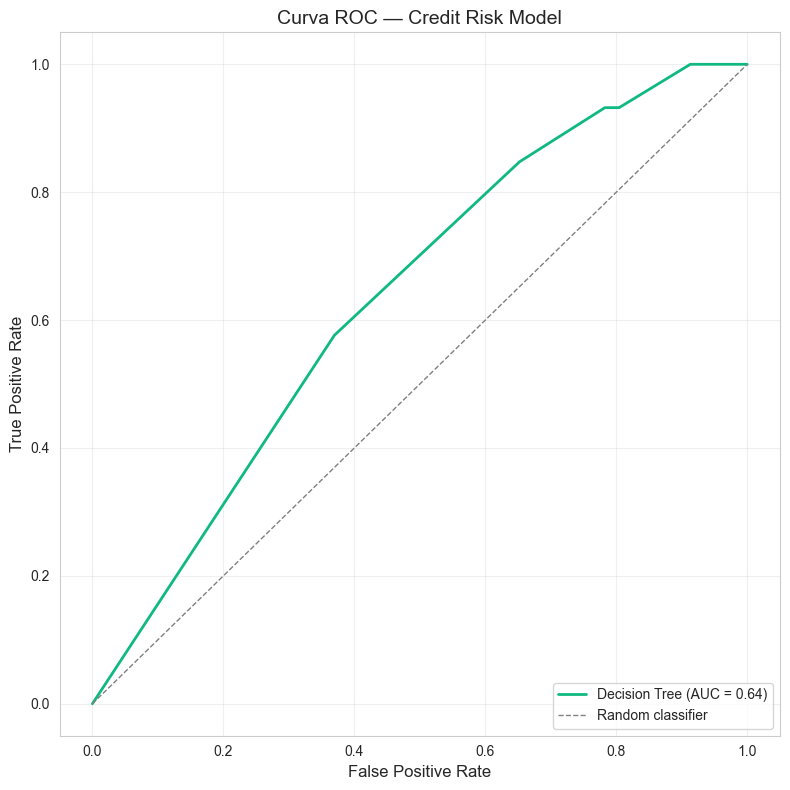

AUC-ROC: 0.6360


In [39]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de predicción (columna 1 = clase "good")
y_proba = best_dt.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr, tpr, color='#10b981', lw=2,
        label=f'Decision Tree (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1,
        linestyle='--', label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curva ROC — Credit Risk Model', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc-curve.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")


In [49]:
import joblib
import sklearn

In [50]:
# 1. Guardar el modelo entrenado (tu Decision Tree)
joblib.dump(dt, 'credit_risk_model.joblib')


['credit_risk_model.joblib']

In [56]:
# 2. Guardar el diccionario de LabelEncoders que creaste en el paso de Feature Engineering
joblib.dump(best_dt, 'credit_risk_model.joblib')

['credit_risk_model.joblib']

In [57]:
joblib.dump(label_encoders, 'label_encoders.joblib')

['label_encoders.joblib']

In [58]:
print("Archivos exportados: credit_risk_model.joblib y label_encoders.joblib")
print(f"Versión de Scikit-Learn: {sklearn.__version__}")

Archivos exportados: credit_risk_model.joblib y label_encoders.joblib
Versión de Scikit-Learn: 1.8.0


SyntaxError: invalid syntax (1746937158.py, line 1)